In [7]:
import pandas as pd
import os
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Asegúrate de poner el nombre exacto que encontraste (respeta mayúsculas)
ruta_archivo = '/content/drive/My Drive/twitter_analysis_dataset/training_twitter.csv'
try:
    # 'latin-1' es la solución estándar para datasets de Twitter antiguos
    df_train = pd.read_csv(ruta_archivo, encoding='latin-1')
    print("¡Archivo cargado exitosamente!")

    # Verificamos rápidamente que los datos se vean bien
    print(df_train.head())

except Exception as e:
    print(f"Error al cargar: {e}")

¡Archivo cargado exitosamente!
   0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY _TheSpecialOne_  \
0  0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   scotthamilton   
1  0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY        mattycus   
2  0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY         ElleCTF   
3  0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY          Karoli   
4  0  1467811372  Mon Apr 06 22:20:00 PDT 2009  NO_QUERY        joy_wolf   

  @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D  
0  is upset that he can't update his Facebook by ...                                                                   
1  @Kenichan I dived many times for the ball. Man...                                                                   
2    my whole body feels itchy and like its on fire                                                                    
3  @nationwideclass no, it's not

In [3]:
ruta_test = '/content/drive/My Drive/twitter_analysis_dataset/testdata_manual.csv'
df_test = pd.read_csv(ruta_test)

In [4]:
# Renombrar columnas para facilitar el análisis
df_train.columns = ['target', 'id', 'date', 'query', 'user', 'text']

# 1. Verificar la distribución de los sentimientos (target)
# Esto es vital para saber si tenemos muchos datos positivos y negativos
print("--- Distribución de sentimientos ---")
print(df_train['target'].value_counts())

# 2. Resumen básico del texto
print("\n--- Ejemplo de limpieza de datos ---")
print(df_train[['target', 'text']].head())

--- Distribución de sentimientos ---
target
4    800000
0    799999
Name: count, dtype: int64

--- Ejemplo de limpieza de datos ---
   target                                               text
0       0  is upset that he can't update his Facebook by ...
1       0  @Kenichan I dived many times for the ball. Man...
2       0    my whole body feels itchy and like its on fire 
3       0  @nationwideclass no, it's not behaving at all....
4       0                      @Kwesidei not the whole crew 


SE REVISA SI HAY VALORES UNICOS (COMO IDs) PARA EVITAR SESGOS EN EL APRENDIZAJE

In [9]:
for col in df_test:
    print(f"Columna '{col}': {df_test[col].nunique()} valores únicos de {len(df_test)} filas.")

Columna '4': 3 valores únicos de 497 filas.
Columna '3': 497 valores únicos de 497 filas.
Columna 'Mon May 11 03:17:40 UTC 2009': 497 valores únicos de 497 filas.
Columna 'kindle2': 81 valores únicos de 497 filas.
Columna 'tpryan': 489 valores únicos de 497 filas.
Columna '@stellargirl I loooooooovvvvvveee my Kindle2. Not that the DX is cool, but the 2 is fantastic in its own right.': 497 valores únicos de 497 filas.


In [10]:
for col in df_train:
    print(f"Columna '{col}': {df_train[col].nunique()} valores únicos de {len(df_train)} filas.")

Columna 'target': 2 valores únicos de 1599999 filas.
Columna 'id': 1598314 valores únicos de 1599999 filas.
Columna 'date': 774362 valores únicos de 1599999 filas.
Columna 'query': 1 valores únicos de 1599999 filas.
Columna 'user': 659775 valores únicos de 1599999 filas.
Columna 'text': 1581465 valores únicos de 1599999 filas.


In [5]:
# Renombrar columnas para facilitar el análisis
df_test.columns = ['target', 'id', 'date', 'query', 'user', 'text']

# 1. Verificar la distribución de los sentimientos (target)
# Esto es vital para saber si tenemos muchos datos positivos y negativos
print("--- Distribución de sentimientos ---")
print(df_test['target'].value_counts())

# 2. Resumen básico del texto
print("\n--- Ejemplo de limpieza de datos ---")
print(df_test[['target', 'text']].head())

--- Distribución de sentimientos ---
target
4    181
0    177
2    139
Name: count, dtype: int64

--- Ejemplo de limpieza de datos ---
   target                                               text
0       4  Reading my kindle2...  Love it... Lee childs i...
1       4  Ok, first assesment of the #kindle2 ...it fuck...
2       4  @kenburbary You'll love your Kindle2. I've had...
3       4  @mikefish  Fair enough. But i have the Kindle2...
4       4  @richardebaker no. it is too big. I'm quite ha...


SE ASEGURA QUE LA COLUMNA ID NO VARIA Y NO PESA EN EL APRENDIZAJE

In [26]:
df_train.columns = ['target', 'id', 'date', 'query', 'user', 'text']
print(df_train[['id']].head())

           id
0  1467810672
1  1467810917
2  1467811184
3  1467811193
4  1467811372


In [25]:
df_test.columns = ['target', 'id', 'date', 'query', 'user', 'text']
print(df_test[['id']].head())

   id
0   4
1   5
2   6
3   7
4   8


EL VALOR UNICO EN LA COLUMNA QUERY DEL DATASET DE TRAIN Y TEST ES IRRELEVANTE PARA EL APRENDIZAJE.

In [13]:
df_test.columns = ['target', 'id', 'date', 'query', 'user', 'text']
print(df_test[['query']].head())

     query
0  kindle2
1  kindle2
2  kindle2
3  kindle2
4  kindle2


In [15]:
print(df_train[['query']].head())

      query
0  NO_QUERY
1  NO_QUERY
2  NO_QUERY
3  NO_QUERY
4  NO_QUERY


Valores nulos en Train:
 target    0
id        0
date      0
query     0
user      0
text      0
dtype: int64

Valores nulos en Test:
 target    0
id        0
date      0
query     0
user      0
text      0
dtype: int64


/tmp/ipykernel_1889/3776109080.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_train, ax=axes[0], palette='viridis')
/tmp/ipykernel_1889/3776109080.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_test, ax=axes[1], palette='magma')


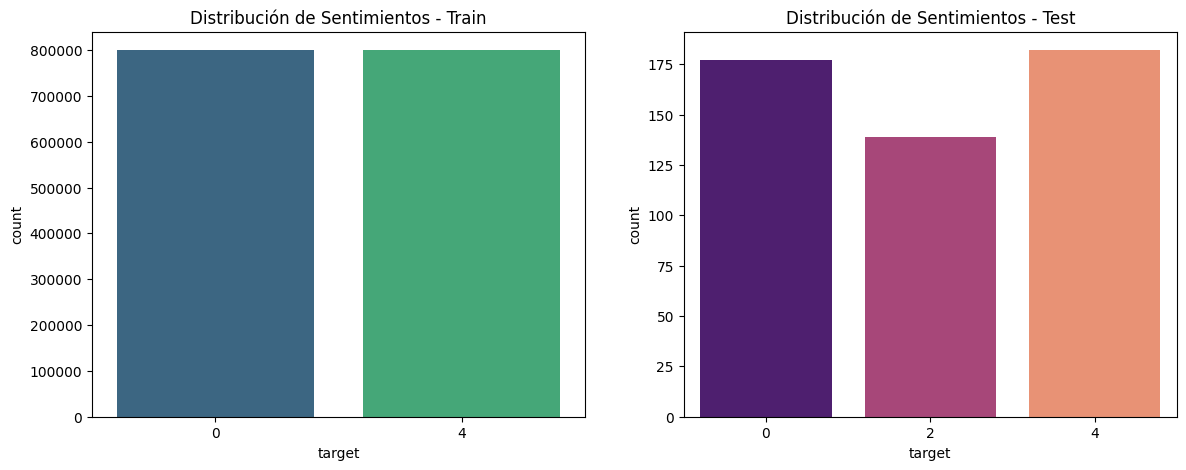

In [8]:

ruta_train = '/content/drive/My Drive/twitter_analysis_dataset/training_twitter.csv'
ruta_test = '/content/drive/My Drive/twitter_analysis_dataset/testdata_manual.csv'

# Cargar
df_train = pd.read_csv(ruta_train, encoding='latin-1', header=None)
df_train.columns = ['target', 'id', 'date', 'query', 'user', 'text']
df_test = pd.read_csv(ruta_test, header=None)
df_test.columns = ['target', 'id', 'date', 'query', 'user', 'text']

# 1. Validación de nulos (esto demuestra limpieza)
print("Valores nulos en Train:\n", df_train.isnull().sum())
print("\nValores nulos en Test:\n", df_test.isnull().sum())

# 2. Gráficos de distribución (esto demuestra análisis visual)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='target', data=df_train, ax=axes[0], palette='viridis')
axes[0].set_title('Distribución de Sentimientos - Train')
sns.countplot(x='target', data=df_test, ax=axes[1], palette='magma')
axes[1].set_title('Distribución de Sentimientos - Test')
plt.show()

Integridad de los datos: Se ha verificado que ambos datasets (train y test) están completos, presentando cero valores nulos en todas sus columnas. Esto elimina la necesidad de realizar imputaciones, asegurando que no se introduzca ruido en el proceso de entrenamiento.  

+ 1
Balanceo del dataset de entrenamiento: El dataset de entrenamiento presenta una distribución perfectamente balanceada, con 800,000 registros para la clase 0 (negativo) y 799,999 para la clase 4 (positivo). Esta simetría es crítica para evitar que el modelo desarrolle sesgos hacia una clase particular durante el aprendizaje.  

+ 1
Observación sobre el conjunto de prueba: Se destaca que el dataset de prueba incluye una tercera clase, target 2 (neutral), la cual no está presente en el conjunto de entrenamiento. Este es un punto de análisis importante, ya que el modelo entrenado con solo dos clases podría intentar clasificar estos casos neutrales forzosamente como positivos o negativos, lo cual debería discutirse en las conclusiones.